In [1]:
# Import libraries

import pandas as pd                 # For data manipulation
import matplotlib.pyplot as plt     # For plotting
import seaborn as sns               # For statistical plots
import prince                       # For doing PCA

In [2]:
# Load the dataset
data = pd.read_csv("Downloads/merged_data.csv")
# Display the first five rows
data.head()

,country,date,Control of Corruption,Rule of Law,GNI_per_capita,Inflation,Trade_as_percent_GDP,Unemployment_rate,GHG_Emissions_per_Capita,Urban_pop_%
0,Albania,2022,-0.408189,-0.165585,5068.146066,6.725203,84.698064,10.137,2.812410,63.799
1,Algeria,2022,-0.638041,-0.833260,4419.867564,9.265516,51.202376,12.346,5.787845,74.772
2,Angola,2022,-0.612376,-1.022036,2160.314444,21.355290,69.691071,14.602,1.886088,68.081
3,Armenia,2022,0.027907,-0.169516,4676.485979,8.640911,101.410778,13.379,3.490671,63.573
4,Australia,2022,1.764367,1.508819,63089.990954,6.594097,45.821770,3.728,21.872898,86.488


In [3]:
# Task 1: Create Income Level variable
# Classify countries based on GNI per capita
def classify_income(gni):
    if gni <= 1145:
        return "Low-income"
    elif gni <= 4515:
        return "Lower middle-income"
    elif gni <= 14005:
        return "Upper middle-income"
    else:
        return "High-income"
# Apply the income classification to each country
data["Income_Level"] = data["GNI_per_capita"].apply(classify_income)
# Check the new Income Level variable
data[["country", "GNI_per_capita", "Income_Level"]].head(10)

,country,GNI_per_capita,Income_Level
0,Albania,5068.146066,Upper middle-income
1,Algeria,4419.867564,Lower middle-income
2,Angola,2160.314444,Lower middle-income
3,Armenia,4676.485979,Upper middle-income
4,Australia,63089.990954,High-income
5,Austria,45302.928453,High-income
6,"Bahamas, The",28705.700350,High-income
7,Bahrain,24056.501104,High-income
8,Belarus,5928.788093,Upper middle-income
9,Belgium,43231.143345,High-income


In [4]:
# Generate dummy variables for each income level
income_dummies = pd.get_dummies(data["Income_Level"], dtype=int)
# Add dummy variables to the dataset
data = pd.concat([data, income_dummies], axis=1)
# Check the dummy variables
data[["Income_Level", "Low-income", "Lower middle-income",
      "Upper middle-income", "High-income"]].head(10)

,Income_Level,Low-income,Lower middle-income,Upper middle-income,High-income
0,Upper middle-income,0,0,1,0
1,Lower middle-income,0,1,0,0
2,Lower middle-income,0,1,0,0
3,Upper middle-income,0,0,1,0
4,High-income,0,0,0,1
5,High-income,0,0,0,1
6,High-income,0,0,0,1
7,High-income,0,0,0,1
8,Upper middle-income,0,0,1,0
9,High-income,0,0,0,1


In [5]:
# Save GNI per capita for the exploratory analysis
gni_data = data["GNI_per_capita"].copy()
# Drop the original GNI variable
data = data.drop(columns=["GNI_per_capita"])
# Check the updated dataset
data.head()

,country,date,Control of Corruption,Rule of Law,Inflation,Trade_as_percent_GDP,Unemployment_rate,GHG_Emissions_per_Capita,Urban_pop_%,Income_Level,High-income,Low-income,Lower middle-income,Upper middle-income
0,Albania,2022,-0.408189,-0.165585,6.725203,84.698064,10.137,2.812410,63.799,Upper middle-income,0,0,0,1
1,Algeria,2022,-0.638041,-0.833260,9.265516,51.202376,12.346,5.787845,74.772,Lower middle-income,0,0,1,0
2,Angola,2022,-0.612376,-1.022036,21.355290,69.691071,14.602,1.886088,68.081,Lower middle-income,0,0,1,0
3,Armenia,2022,0.027907,-0.169516,8.640911,101.410778,13.379,3.490671,63.573,Upper middle-income,0,0,0,1
4,Australia,2022,1.764367,1.508819,6.594097,45.821770,3.728,21.872898,86.488,High-income,1,0,0,0


In [6]:
# Task 2: Create boxplots to identify outliers
# List of continuous variables
variables = [
    "Control of Corruption",
    "Rule of Law",
    "GNI_per_capita",
    "Inflation",
    "Trade_as_percent_GDP",
    "Unemployment_rate",
    "GHG_Emissions_per_Capita",
    "Urban_pop_%"]
# Create a copy of the data for boxplots
boxplot_data = data.copy()
# Add GNI per capita back for exploratory analysis
boxplot_data["GNI_per_capita"] = gni_data

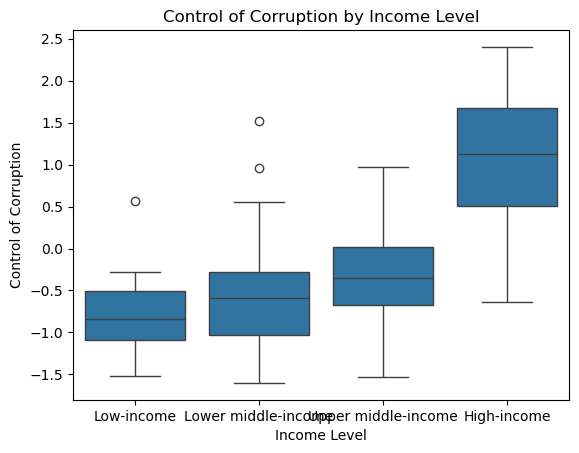

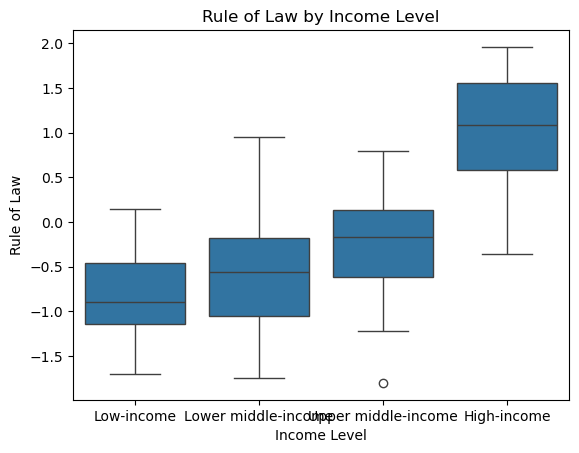

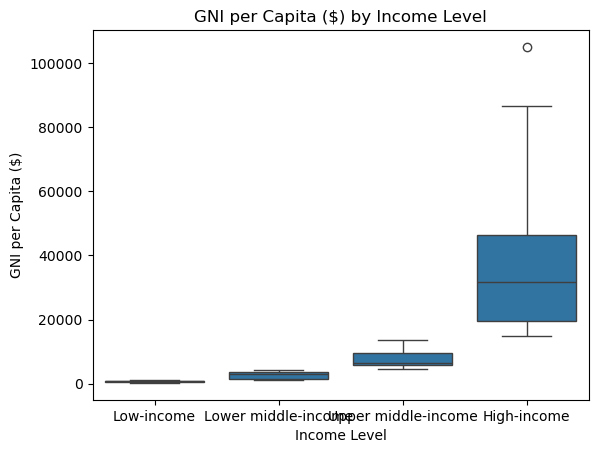

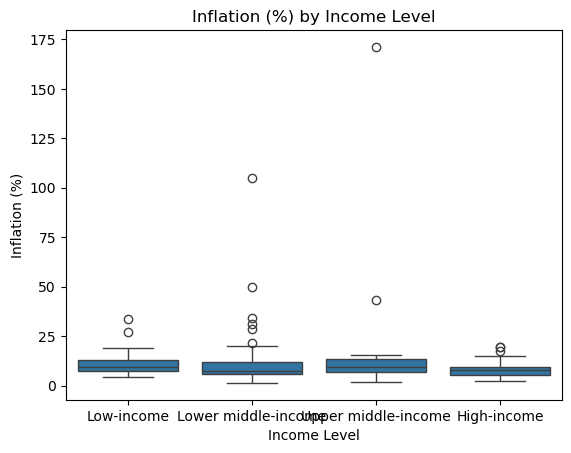

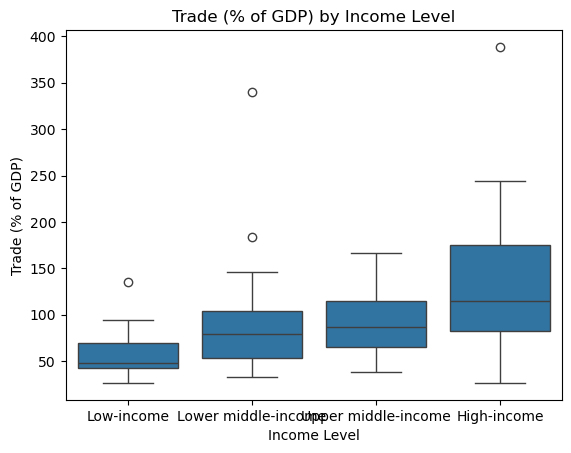

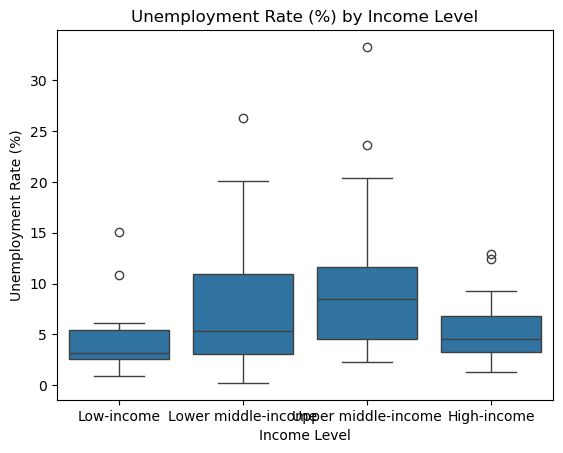

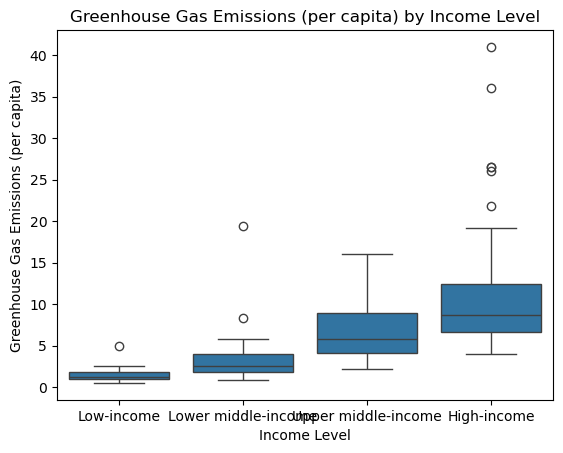

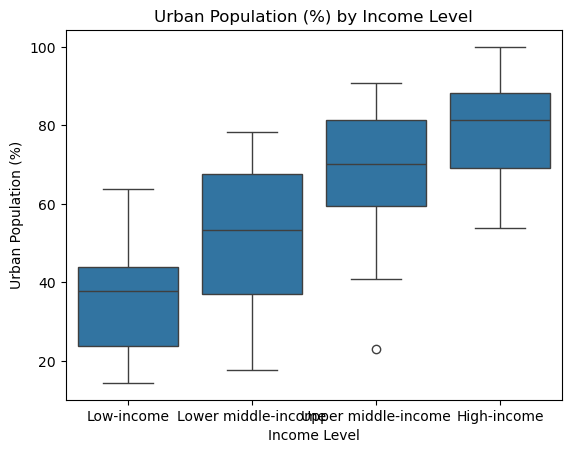

In [7]:
# Set the required order for income levels
income_order = [
    "Low-income",
    "Lower middle-income",
    "Upper middle-income",
    "High-income"]
# Create formatted labels for each variable
variable_labels = {
    "Control of Corruption": "Control of Corruption",
    "Rule of Law": "Rule of Law",
    "GNI_per_capita": "GNI per Capita ($)",
    "Inflation": "Inflation (%)",
    "Trade_as_percent_GDP": "Trade (% of GDP)",
    "Unemployment_rate": "Unemployment Rate (%)",
    "GHG_Emissions_per_Capita": "Greenhouse Gas Emissions (per capita)",
    "Urban_pop_%": "Urban Population (%)"}
# Create boxplots for each variable by income level
for variable in variables:
    plt.figure()
    sns.boxplot(
        data=boxplot_data,
        x="Income_Level",
        y=variable,
        order=income_order )
    plt.title(variable_labels[variable] + " by Income Level")
    plt.xlabel("Income Level")
    plt.ylabel(variable_labels[variable])
    plt.show()

In [8]:
# Calculate summary statistics by income level
summary_stats = boxplot_data.groupby("Income_Level")[variables].agg(
    ["mean", "median"])
summary_stats

Control of Corruption           Rule of Law            \
                                     mean    median        mean    median   
Income_Level                                                                
High-income                      1.060875  1.129880    1.055817  1.080364   
Low-income                      -0.772103 -0.839937   -0.841747 -0.890501   
Lower middle-income             -0.548406 -0.586780   -0.541496 -0.557186   
Upper middle-income             -0.331556 -0.347401   -0.242317 -0.167550   

                    GNI_per_capita                Inflation            \
                              mean        median       mean    median   
Income_Level                                                            
High-income           37438.379438  31650.896760   8.213370  7.763012   
Low-income              757.076711    794.422445  12.224084  9.507657   
Lower middle-income    2720.238504   3027.557245  13.200451  7.429239   
Upper middle-income    7727.244188   6469.858502  15.678171  9.522836   

                    Trade_as_percent_GDP             Unemployment_rate  \
                                    mean      median              mean   
Income_Level                                                             
High-income                   129.763018  115.350270          5.189429   
Low-income                     58.993486   48.167826          4.443500   
Lower middle-income            89.296277   79.034504          7.665250   
Upper middle-income            93.061967   86.997696          9.701833   

                            GHG_Emissions_per_Capita           Urban_pop_%  \
                     median                     mean    median        mean   
Income_Level                                                                 
High-income          4.5445                11.905326  8.765284   79.200405   
Low-income           3.1805                 1.529245  1.241618   35.255812   
Lower middle-income  5.3140                 3.280564  2.579851   50.796025   
Upper middle-income  8.5060                 6.484505  5.761671   68.296833   

                              
                      median  
Income_Level                  
High-income          81.4680  
Low-income           37.9275  
Lower middle-income  53.3110  
Upper middle-income  70.2795

### Task 2 Observations

Looking at the boxplots, there are some clear differences between the income levels. High-income countries have higher Control of Corruption and Rule of Law scores, with medians of 1.13 and 1.08. Low-income countries have much lower medians of -0.84 and -0.89. GNI per capita also increases as the income level increases, which makes sense since GNI is what was used to create the income groups.

Inflation stood out to me because there are several high outliers. For some of the income groups, the mean is much higher than the median, which shows that a few countries with really high inflation are pulling the average up. There were also noticeable outliers for trade, unemployment, and greenhouse gas emissions.

Another thing I noticed is that greenhouse gas emissions and urban population generally increase with income level. The median greenhouse gas emissions increased from 1.24 for low-income countries to 8.77 for high-income countries. The same pattern can be seen with urban population, which increased from a median of 37.93% for low-income countries to 81.47% for high-income countries.

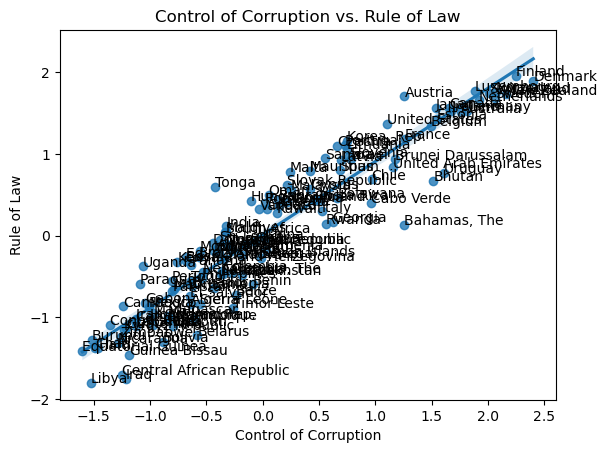

In [9]:
# Task 6: Scatterplot of Control of Corruption vs. Rule of Law
# Create scatterplot with regression line
sns.regplot(
    data=data,
    x="Control of Corruption",
    y="Rule of Law")
# Label each point with the country name
for i in range(len(data)):
    plt.annotate(
        data["country"].iloc[i],
        (data["Control of Corruption"].iloc[i],
         data["Rule of Law"].iloc[i]))
# Add title and axis labels
plt.title("Control of Corruption vs. Rule of Law")
plt.xlabel("Control of Corruption")
plt.ylabel("Rule of Law")
plt.show()

In [10]:
# Calculate the correlation between Control of Corruption and Rule of Law
correlation = data["Control of Corruption"].corr(data["Rule of Law"])
print("Correlation:", correlation)

Correlation: 0.940457409647809


### Task 6 Observation

Looking at the scatterplot, there is a clear positive relationship between Control of Corruption and Rule of Law. The correlation is about 0.94, which shows that the relationship between the two is very strong. As the Control of Corruption score increases, the Rule of Law score also tends to increase. There are some countries that stand out from the rest, but they do not really change the overall pattern. This relationship makes sense to me because I would expect countries with better control over corruption to also have stronger laws and institutions.

In [11]:
# Task 7: Prepare the data for PCA
# Select the variables to use in PCA
pca_variables = [
    "Control of Corruption",
    "Rule of Law",
    "Inflation",
    "Trade_as_percent_GDP",
    "Unemployment_rate",
    "GHG_Emissions_per_Capita",
    "Urban_pop_%",
    "Low-income",
    "Lower middle-income",
    "Upper middle-income",
    "High-income"]
# Create the PCA dataset
X = data[pca_variables].astype(float)
# Display the first five rows
X.head()

,Control of Corruption,Rule of Law,Inflation,Trade_as_percent_GDP,Unemployment_rate,GHG_Emissions_per_Capita,Urban_pop_%,Low-income,Lower middle-income,Upper middle-income,High-income
0,-0.408189,-0.165585,6.725203,84.698064,10.137,2.812410,63.799,0.0,0.0,1.0,0.0
1,-0.638041,-0.833260,9.265516,51.202376,12.346,5.787845,74.772,0.0,1.0,0.0,0.0
2,-0.612376,-1.022036,21.355290,69.691071,14.602,1.886088,68.081,0.0,1.0,0.0,0.0
3,0.027907,-0.169516,8.640911,101.410778,13.379,3.490671,63.573,0.0,0.0,1.0,0.0
4,1.764367,1.508819,6.594097,45.821770,3.728,21.872898,86.488,0.0,0.0,0.0,1.0


In [12]:
# Run PCA with 5 components
pca = prince.PCA(
    n_components=5,
    rescale_with_mean=True,
    rescale_with_std=True,)
# Fit the PCA model to the standardized data
pca = pca.fit(X)

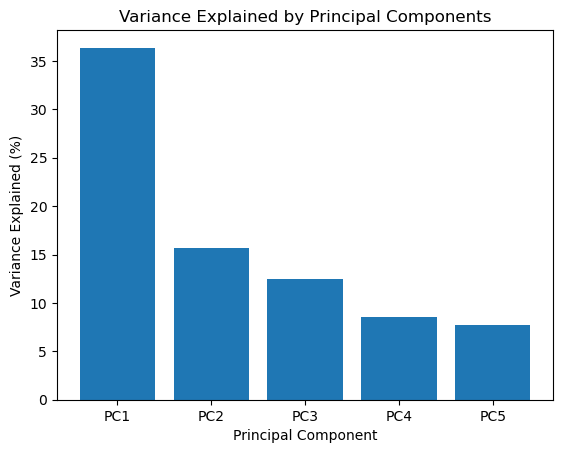

In [13]:
# Calculate the percentage of variance explained
variance_explained = pca.percentage_of_variance_
# Create labels for the five principal components
components = ["PC1", "PC2", "PC3", "PC4", "PC5"]
# Create a barplot of variance explained
plt.bar(components, variance_explained)
plt.title("Variance Explained by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.show()

In [14]:
# Check the variance explained by each component
variance_explained

array([36.36930983, 15.66616734, 12.43199994,  8.55523348,  7.71428449])

### Task 7 Variance Explained Observation

Looking at the barplot, PC1 explains the largest amount of variance at about 36.37%. PC2 explains about 15.67% and PC3 explains about 12.43%, with the amount continuing to decrease for PC4 and PC5. The first two components together explain about 52.04% of the variance, while all five components explain about 80.74%. This shows that a little over half of the information in the data can be represented by the first two components.

In [15]:
# Calculate PCA coordinates for each country
row_coordinates = pca.row_coordinates(X)
# Calculate squared cosines for observations
row_cos2 = pca.row_cosine_similarities(X)
# Calculate squared cosines for the first two principal components
observation_cos2 = row_cos2.iloc[:, 0] + row_cos2.iloc[:, 1]
# Display the first five squared cosine values
observation_cos2.head()

0    0.594895
1    0.327859
2    0.475681
3    0.670308
4    0.740513
dtype: float64

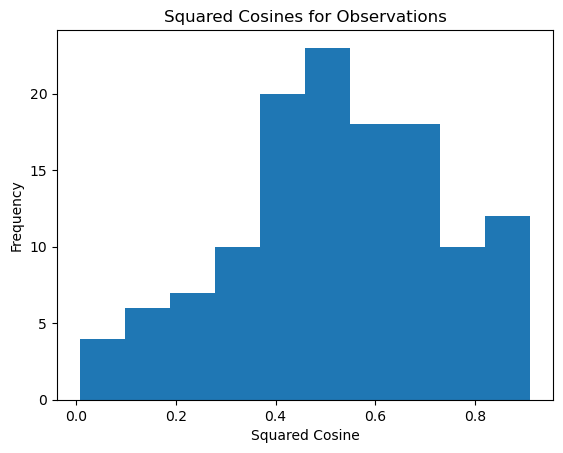

In [16]:
# Create a histogram of squared cosines for observations
plt.hist(observation_cos2)
plt.title("Squared Cosines for Observations")
plt.xlabel("Squared Cosine")
plt.ylabel("Frequency")
plt.show()

In [17]:
# Calculate variable correlations with principal components
variable_correlations = pca.column_correlations
# Calculate squared cosines for variables
column_cos2 = pca.column_cosine_similarities_
# Calculate squared cosines using PC1 and PC2
variable_cos2 = column_cos2.iloc[:, 0] + column_cos2.iloc[:, 1]
variable_cos2

variable
Control of Corruption       0.776659
Rule of Law                 0.796783
Inflation                   0.108051
Trade_as_percent_GDP        0.223808
Unemployment_rate           0.464133
GHG_Emissions_per_Capita    0.469831
Urban_pop_%                 0.691981
Low-income                  0.446596
Lower middle-income         0.262798
Upper middle-income         0.618395
High-income                 0.864865
dtype: float64

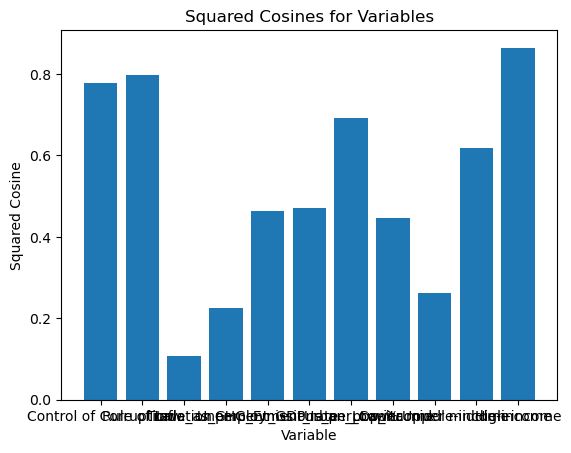

In [18]:
# Create a vertical barplot of squared cosines for variables
plt.bar(variable_cos2.index, variable_cos2.values)
plt.title("Squared Cosines for Variables")
plt.xlabel("Variable")
plt.ylabel("Squared Cosine")
plt.show()

### Task 7 Squared Cosine Observation

Looking at the barplot, High-income has the highest squared cosine at about 0.86. Rule of Law is about 0.80 and Control of Corruption is about 0.78. This tells me that these variables are represented better by the first two principal components. Inflation stood out as the lowest at about 0.11, meaning PC1 and PC2 do not represent it as well.

Looking at the countries, Korea, Germany, the Netherlands, Czechia, and Norway have some of the highest squared cosine values, so they are represented well by PC1 and PC2. Mongolia and Cabo Verde stood out with the lowest values at less than 0.01. This shows that the first two components do not represent every country equally, and some countries may be better explained by the other components.

In [19]:
# Identify countries with the highest and lowest squared cosines
country_cos2 = pd.DataFrame({
    "Country": data["country"],
    "Squared Cosine": observation_cos2})
country_cos2.sort_values("Squared Cosine")

,Country,Squared Cosine
85,Mongolia,0.006839
20,Cabo Verde,0.007900
97,Panama,0.063744
119,Tonga,0.096703
88,Namibia,0.105404
...,...,...
94,Norway,0.874254
33,Czechia,0.880777
90,Netherlands,0.883335
48,Germany,0.885089


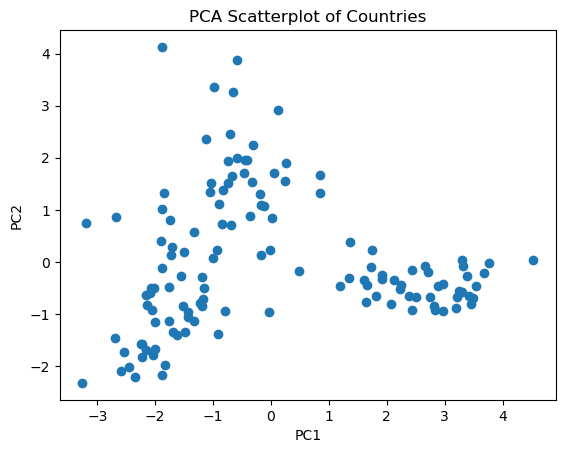

In [20]:
# Task 8: PCA scatterplot of countries
plt.scatter(
    row_coordinates[0],
    row_coordinates[1])
plt.title("PCA Scatterplot of Countries")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

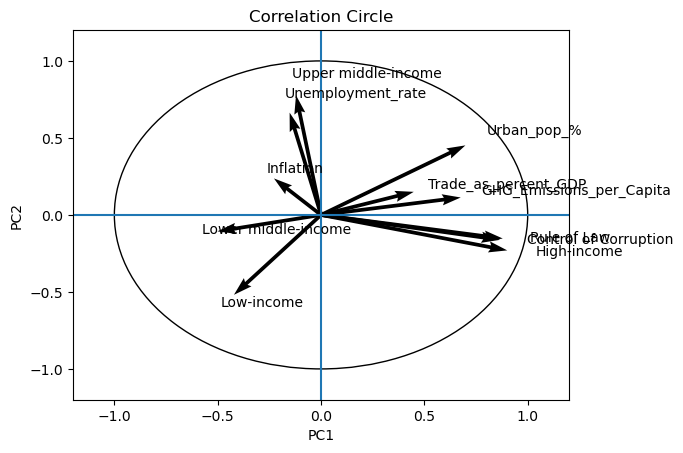

In [21]:
# Task 8: Correlation Circle
correlation_coordinates = pca.column_coordinates_
ax = plt.gca()
ax.add_artist(plt.Circle((0, 0), 1, fill=False))
for i, (x, y) in enumerate(zip(correlation_coordinates[0],
                               correlation_coordinates[1])):
    ax.quiver(0, 0, x, y, angles="xy", scale_units="xy", scale=1)
    ax.text(x * 1.15, y * 1.15, pca_variables[i])
plt.axhline(0)
plt.axvline(0)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Correlation Circle")
plt.show()

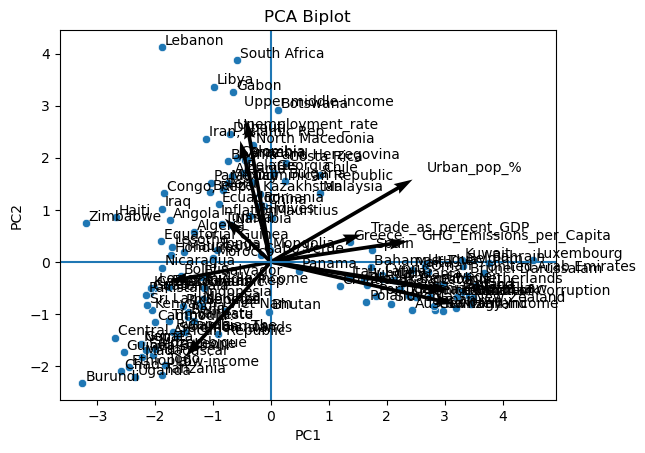

In [22]:
# Task 8: PCA Biplot
# Plot country observations
sns.scatterplot(
    x=row_coordinates[0],
    y=row_coordinates[1])
# Label each country
for i, (x, y) in enumerate(zip(row_coordinates[0], row_coordinates[1])):
    plt.text(x + 0.05, y + 0.05, data["country"].iloc[i])
# Scale the variable arrows
scale = 3.5
coords = (correlation_coordinates.iloc[:, :2] * scale).values
# Plot variable arrows
for i, (x, y) in enumerate(coords):
    plt.quiver(0, 0, x, y, angles="xy", scale_units="xy", scale=1)
    plt.text(x * 1.1, y * 1.1, pca_variables[i])
# Add reference lines and labels
plt.axhline(0)
plt.axvline(0)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")
plt.show()

In [23]:
variable_correlations

component,0,1,2,3,4
variable,,,,,
Control of Corruption,0.866302,-0.161802,0.023678,0.002874,0.023784
Rule of Law,0.879387,-0.153170,0.017598,0.011905,0.008533
Inflation,-0.227825,0.236953,-0.055963,0.937107,-0.003820
Trade_as_percent_GDP,0.448695,0.149937,0.280383,0.065977,0.663073
Unemployment_rate,-0.151936,0.664115,0.182156,-0.151935,0.389713
GHG_Emissions_per_Capita,0.676026,0.113225,-0.078545,0.016013,-0.290947
Urban_pop_%,0.698615,0.451573,0.006187,-0.007432,-0.139464
Low-income,-0.421357,-0.518704,-0.594054,-0.009891,0.318370
Lower middle-income,-0.501412,-0.106697,0.827534,-0.006099,-0.178341


### Task 8 Observation

Looking at the PCA results, PC1 explains the most variance at about 36.37%. High-income, Rule of Law, and Control of Corruption have some of the strongest relationships with PC1. Urban population and greenhouse gas emissions also have a positive relationship with it. This tells me that these variables play a bigger part in what PC1 is showing about the differences between the countries.

PC2 explains about 15.67% of the variance and stood out more with Upper middle-income and unemployment. The other components seem to pick up information that PC1 and PC2 do not explain as much. Inflation really stood out with PC4 at about 0.94, while trade had its strongest relationship with PC5 at about 0.66.

Looking at the scatterplot and biplot, countries that are closer together have more similar patterns, while countries that are farther apart show more differences. The Income level also seems to be part of this grouping. High-income has a strong positive relationship with PC1, while Low-income and Lower middle-income have negative relationships with PC1. The correlation circle also shows which variables have similar relationships and which ones move in different directions. Overall, the first five components explain about 80.74% of the variance, so most of the information from the original data is still represented after using PCA.